In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

ModuleNotFoundError: No module named 'google'

In [2]:
import cv2

In [ ]:
%%shell
pip install cython
pip install -U 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'

UsageError: Cell magic `%%shell` not found.


In [ ]:
import os
import numpy as np
import torch
import torch.utils.data
from PIL import Image

diff_objs = []
m = {}
label_map = {}

#label_map[14] = 1
label_map[38] = 1
label_map[75] = 2
#label_map[113] = 4
#label_map[52] = 3
label_map[89] = 3
label_map[128] = 4
label_map[19] = 5

import re
def sorted_alphanumeric(data):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [ convert(c) for c in re.split('([0-9]+)', key) ]
    return sorted(data, key=alphanum_key)

class TestDataSet(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms

        # Grab all files, but ONLY keep the ones that end in image extensions
        all_files = os.listdir(root)
        valid_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        self.imgs = list(sorted_alphanumeric(valid_images))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.imgs[idx])
        img = Image.open(img_path).convert("RGB")

        image_id = torch.tensor([idx])

        target = {}
        # boxes looks like: [xmin, ymin, xmax, ymax]
        target["boxes"] = None
        target["labels"] = None
        target["masks"] = None
        target["image_id"] = None
        target["area"] = None
        target["iscrowd"] = None

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [ ]:
%%shell

# Download TorchVision repo to use some files from
# references/detection
# Only clone if the directory doesn't exist
if [ ! -d "vision" ]; then
  git clone https://github.com/pytorch/vision.git
fi
cd vision
git checkout v0.3.0

cp references/detection/utils.py ../
cp references/detection/transforms.py ../
cp references/detection/coco_eval.py ../
cp references/detection/engine.py ../
cp references/detection/coco_utils.py ../

HEAD is now at be376084d8 version check against PyTorch's CUDA version


In [ ]:
import sys
import types
sys.modules['torch._six'] = types.ModuleType('torch.six')


from engine import train_one_epoch, evaluate
import utils
import transforms as T

def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())

    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

In [ ]:
dataset_test = TestDataSet("/content/gdrive/MyDrive/PE_Saumya_Shankar/Resources/Glioma/Insular/2013-12-23 115852_L insular glioma/segment38_frames", get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=2,
    collate_fn=utils.collate_fn)

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def get_instance_segmentation_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model


num_classes = 6
model = get_instance_segmentation_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

model.load_state_dict(torch.load("/content/gdrive/MyDrive/PE_Saumya_Shankar/Resources/model_frames_1_5class_5july_new15_model.pt", map_location=torch.device('cpu')))

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

(480, 640, 3)


[{'boxes': tensor([[170.2338,  89.6588, 639.1086, 164.5538],
          [356.6594, 106.9545, 637.7798, 161.9592],
          [137.6965,  84.6441, 640.0000, 194.4575]]),
  'labels': tensor([1, 1, 4]),
  'scores': tensor([0.8798, 0.2567, 0.0889]),
  'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0.,

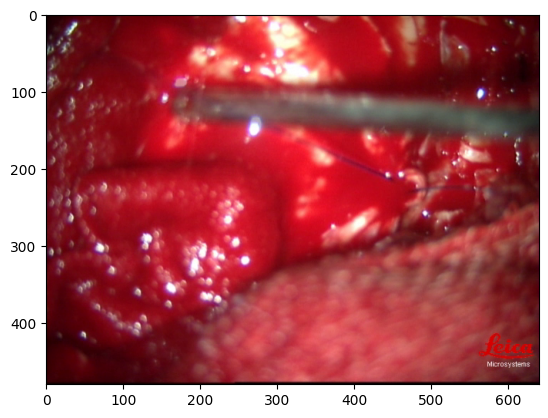

In [ ]:
import cv2

img, _ = dataset_test[6]
model.eval()

with torch.no_grad():
    prediction = model([img.to(device)])
img = np.asarray(img)
img = np.moveaxis(img,0,2)
print(np.shape(img))
import matplotlib.pyplot as plt
plt.imshow(img)
prediction

tensor([1, 1, 4])
(3, 1, 480, 640)


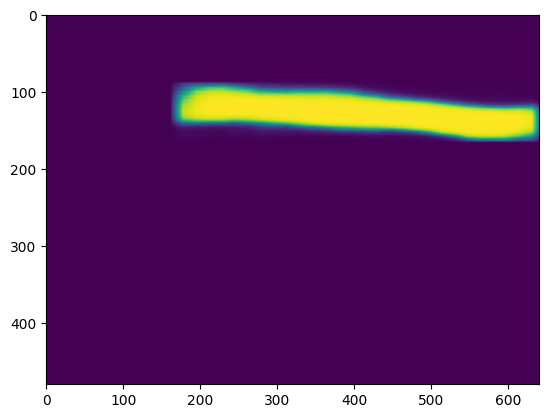

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print(prediction[0]['labels'])
masks = prediction[0]['masks'].cpu().detach().numpy()
print(np.shape(masks))
plt.imshow(masks[0,0,:,:])

In [ ]:
def good_predictions(predictions, threshold):
  new_prediction = predictions[0]
  count = 0
  siz = np.shape(new_prediction['scores'].cpu().detach().numpy())

  for score in predictions[0]['scores']:
    if score < threshold:
      count += 1

  new_prediction['labels'] = new_prediction['labels'][:siz[0]-count]
  new_prediction['boxes'] = new_prediction['boxes'][:siz[0]-count]
  new_prediction['masks'] = new_prediction['masks'][:siz[0]-count]
  new_prediction['scores'] = new_prediction['scores'][:siz[0]-count]
  return [new_prediction]

In [ ]:
def check_inside(box1, box2):
    # box format: [xmin, ymin, xmax, ymax]

    # Check if box2 is inside box1
    if (box2[0] >= box1[0] and box2[1] >= box1[1] and
        box2[2] <= box1[2] and box2[3] <= box1[3]):
        return 2 # Box 2 is inside Box 1

    # Check if box1 is inside box2
    elif (box1[0] >= box2[0] and box1[1] >= box2[1] and
          box1[2] <= box2[2] and box1[3] <= box2[3]):
        return 1 # Box 1 is inside Box 2

    else:
        return 0 # No containment


In [ ]:
def iou_masks(result1, result2):
  intersection = np.logical_and(result1, result2)
  union = np.logical_or(result1, result2)
  iou_score = np.sum(intersection) / np.sum(union)
  return iou_score

In [ ]:
from skimage.morphology import medial_axis, skeletonize

480
640


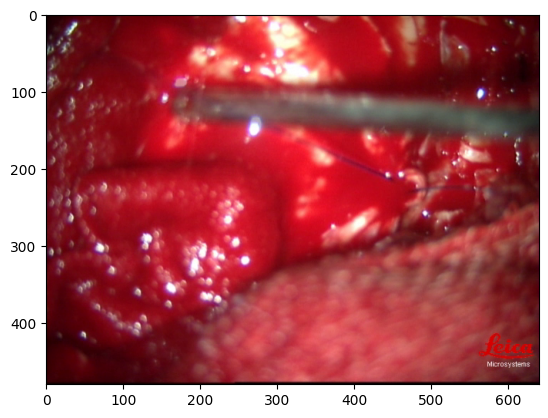

In [ ]:
img, _ = dataset_test[6]
ih,iw = np.shape(np.asarray(img))[1:3]
print(ih)
print(iw)
width_diff = max(0, (ih-iw)//2)
height_diff = max(0, (iw-ih)//2)
img = np.moveaxis(np.asarray(img),0,2)
plt.imshow(img)

In [ ]:
def get_scores_predictions_and_embeddings(model, preds, ih, iw, frame_id, add_appearance=False, repp_format=True):
  import torchvision.transforms as transforms
  import torch.nn.functional as F
  preds_frame = []
  for i in range(len(preds[0]['boxes'])):
    scores_conf = preds[0]['scores'][i].cpu().detach().item()
    width_diff = max(0, (ih-iw)//2)
    height_diff = max(0, (iw-ih)//2)


# # We take square image because neural networks often resize images to be square.

###### New Code #################
    # Extract the four corners from your model's output
    x_min, y_min, x_max, y_max = preds[0]['boxes'][i].cpu().detach().numpy()

    # Calculate actual width and height
    width = x_max - x_min
    height = y_max - y_min

    if width <= 0 or height <= 0: continue

    # Now the center calculation is mathematically accurate
    bbox_center = [ (x_min + width_diff + width/2)/max(iw,ih),
                    (y_min + height_diff + height/2)/max(iw,ih)]
####### Till here #################



    # Initialize predictions
    pred = { 'image_id': frame_id, 'bbox': [ x_min, y_min, width, height ], 'bbox_center': bbox_center }

    if add_appearance:
      roi_x_min, roi_y_min = dx + x_min*scale, dy + y_min*scale
      roi_width = width*scale; roi_height = height*scale
      roi_width = max(1., roi_width); roi_height = max(1., roi_height)
      emb = branch_model.predict([preds[2][0], np.array([[[roi_x_min, roi_y_min, roi_width, roi_height]]])])[0]
      pred['emb'] = emb

    if repp_format:
      scoreval = preds[0]['scores'][i].cpu().detach().item()
      uniform = (1 - scoreval)/8
      scorres =[1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform,1.0*uniform]
      scorres[preds[0]['labels'][i]] = scoreval
      pred['scores'] = scorres
      pred['scores'] = F.one_hot(preds[0]['labels'][i], num_classes=6).cpu().detach().numpy()

    preds_frame.append(pred)
  return preds_frame

In [ ]:
import pickle
import torchvision.transforms as transforms
import torch.nn.functional as F

In [ ]:
from skimage.morphology import medial_axis, skeletonize
def euclidian_distance(a, b):
      return np.linalg.norm(a - b)

In [ ]:
no_frames = 40
position = np.zeros((6, no_frames+1, 2),dtype=int)
preds1=[]
preds2=[]
preds3=[]

overlap1=[]

overlap2=[]

dataset_labels = []
preds_video = {}
frame_id = 0
for index in range(0, no_frames):
  frame_id = frame_id+1
  print(index)

  img, _ = dataset_test[index]
  ih, iw = np.shape(np.asarray(img))[1:3]
  if frame_id <= no_frames:
    import matplotlib.pyplot as plt
    img_to_display = img.cpu().detach().numpy()
    img_to_display = np.moveaxis(img_to_display, 0, 2)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_to_display)
    plt.title(f"Processed Image for Frame {frame_id}")
    plt.axis('off')
    plt.show()


  with torch.no_grad():
    preds = good_predictions(model([img.to(device)]), 0.3)
    print(preds[0]['labels'])

  preds1.append(preds[0]['labels'].cpu().detach().numpy())

  overlap=[]
  masks = preds[0]['masks'].cpu().detach().numpy()
  for i in range(0,np.shape(masks)[0]-1):
    for j in range(i+1,np.shape(masks)[0]):
      iou_score = iou_masks(masks[i,0,:,:],masks[j,0,:,:])
      if iou_score > 0.2:
        if(preds[0]['scores'][i]>preds[0]['scores'][j]):
          print("predictionscore of ",preds[0]['labels'][i],"\">= ",preds[0]['labels'][j])
          overlap.append(j)
        else:
          print("predictionscore of ",preds[0]['labels'][j],"\">= ",preds[0]['labels'][i])
          overlap.append(i)

  overlap = np.asarray(overlap,dtype=int)

  overlap1.append(overlap)
  for i in range(0,np.shape(overlap)[0]):
    id = overlap[i]-i
    preds[0]['scores']= torch.cat([preds[0]['scores'][0:id], preds[0]['scores'][id+1:]])
    preds[0]['labels']= torch.cat([preds[0]['labels'][0:id], preds[0]['labels'][id+1:]])
    preds[0]['boxes']= torch.cat([preds[0]['boxes'][0:id], preds[0]['boxes'][id+1:]])
    preds[0]['masks']= torch.cat([preds[0]['masks'][0:id], preds[0]['masks'][id+1:]])
  preds2.append(preds[0]['labels'].cpu().detach().numpy())


  overlap=[]
  boxes = preds[0]['boxes'].cpu().detach().numpy()
  for i in range(0,np.shape(boxes)[0]-1):
    for j in range(i+1,np.shape(boxes)[0]):
      inside_index = check_inside(boxes[i,:],boxes[j,:])
      if inside_index == 1:
        overlap.append(i)
      if inside_index == 2:
        overlap.append(j)


  overlap = np.asarray(overlap,dtype=int)
  overlap2.append(overlap)
  for i in range(0,np.shape(overlap)[0]):
    id = overlap[i]-i
    preds[0]['scores']= torch.cat([preds[0]['scores'][0:id], preds[0]['scores'][id+1:]])
    preds[0]['labels']= torch.cat([preds[0]['labels'][0:id], preds[0]['labels'][id+1:]])
    preds[0]['boxes']= torch.cat([preds[0]['boxes'][0:id], preds[0]['boxes'][id+1:]])
    preds[0]['masks']= torch.cat([preds[0]['masks'][0:id], preds[0]['masks'][id+1:]])


  preds3.append(preds[0]['labels'].cpu().detach().numpy())
  masks = preds[0]['masks'].cpu().detach().numpy()
  preds_frame = get_scores_predictions_and_embeddings(model, preds, ih, iw, frame_id,  add_appearance=False, repp_format=True)
  preds_video[frame_id] = preds_frame


store_filename = "/content/gdrive/MyDrive/PE_Saumya_Shankar/Resources/repp_input_2_inst_sam_31may.pckl"
file_writter = open(store_filename, 'wb')
last_video = frame_id
pickle.dump((frame_id,preds_video), file_writter)
file_writter.close()

In [ ]:
np.save("/content/gdrive/MyDrive/PE_Saumya_Shankar/Resources/Position.npy",position)

In [ ]:
for i in range (0,np.shape(preds[0]['labels'])[0]):
    mask1 = masks[i,0,:,:]
    mask1[mask1>0.7] = 1
    mask1 = mask1.astype(int)
    blobs = mask1

    skel, distance = medial_axis(blobs, return_distance=True)

    skeleton = skeletonize(blobs)

    skeleton_lee = skeletonize(blobs, method='lee')

    img = skeleton_lee

    (rows,cols) = np.nonzero(img)

    skel_coords = []

    for (r,c) in zip(rows,cols):
      (col_neigh,row_neigh) = np.meshgrid(np.array([c-1,c,c+1]), np.array([r-1,r,r+1]))
      col_neigh = col_neigh.astype('int')
      row_neigh = row_neigh.astype('int')
      pix_neighbourhood = img[row_neigh,col_neigh].ravel() != 0
      if np.sum(pix_neighbourhood) == 2:
          skel_coords.append((r,c))

    coord = np.asarray(skel_coords)

    def euclidian_distance(a, b):
      return np.linalg.norm(a - b)

    img_centre = np.array([np.shape(img)[0]/2,np.shape(img)[1]/2])

    coords = sorted(coord, key=lambda point: euclidian_distance(point, img_centre))
    coords = np.asarray(coords)
    del coord

    if np.shape(coords)[0]==2:
      n=1
    if np.shape(coords)[0]>2:
      n=2

    centre_coord = coords[0,:]
    id = np.asarray(index, dtype = int)
    position[preds[0]['labels'][i],id,0:2] = centre_coord



In [ ]:
print(preds_frame)

[{'image_id': 40, 'bbox': [np.float32(336.29614), np.float32(0.0), np.float32(109.23706), np.float32(174.46179)], 'bbox_center': [np.float32(0.6108042), np.float32(0.26129827)], 'scores': array([0, 0, 0, 0, 0, 1])}]


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# VISUALIZATION OF FRAMES
# ==========================================

tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar Forceps',
    4: 'Dissecting Forceps',
    5: 'Other'
}


TOOL_COLORS = {
    1: 'red',        # Suction
    2: 'lime',       # Cusa
    3: 'cyan',       # Bipolar Forceps
    4: 'yellow',     # Dissecting Forceps
    5: 'orange'      # Other
}

def visualize_verification(frame_id):
    """
    Plots the image for a specific frame_id with the FINAL corrected boxes.
    """
    try:
        dataset_index = frame_id - 1
        img_tensor, _ = dataset_test[dataset_index]

        img_np = img_tensor.cpu().detach().numpy()
        img_np = np.moveaxis(img_np, 0, 2)
    except IndexError:
        print(f"Error: Frame ID {frame_id} (Index {dataset_index}) is out of bounds.")
        return

    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(img_np)
    ax.set_title(f"Frame {frame_id} - Final Output", fontsize=15)
    ax.axis('off')

    if frame_id in preds_video:
        detections = preds_video[frame_id]

        for det in detections:
            if 'scores' in det:
                label_id = np.argmax(det['scores'])
            else:
                continue

            if label_id == 0: continue # Skip background
            tool_name = tool_label_to_name.get(label_id, f"Unknown-{label_id}")
            color = TOOL_COLORS.get(label_id, 'white')

            bbox = det['bbox']
            x, y, w, h = bbox

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)

            label_text = f"{tool_name}"

            plt.text(
                x, y - 8,
                label_text,
                color='black',
                fontsize=10,
                fontweight='bold',
                bbox=dict(facecolor=color, edgecolor=color, alpha=0.7, pad=2)
            )

    plt.show()

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim
import numpy as np

import matplotlib.pyplot as plt

from typing import List

# ==============================================================================
# POST-PROCESSING: DSU (Cell 1)
# ==============================================================================

def plot_image(img: torch.Tensor, title: str = None):
    """
    img: torch tensor of shape (3, W, H), values in [0,1] or [0,255]
    """

    assert img.ndim == 3, "Expected a 3D tensor"
    assert img.shape[0] == 3, "Expected image format (3, W, H)"

    # Convert to (H, W, 3) for matplotlib
    img_np = img.permute(1, 2, 0).cpu().numpy()

    # If values are in [0,255], normalize for display
    if img_np.max() > 1.0:
        img_np = img_np / 255.0

    img_np = img_np.clip(0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()

def image_similarity_ssim(img1: torch.Tensor, img2: torch.Tensor):
    """
    img1, img2: tensors of shape (3, W, H), values in [0,1]

    returns:
        score: float in [-1, 1] (higher = more similar)
        diff_map: (W, H) numpy array highlighting differences
    """

    assert img1.shape == img2.shape

    # Convert to grayscale (tools pop more than color)
    img1_gray = torch.mean(img1, dim=0).cpu().numpy()
    img2_gray = torch.mean(img2, dim=0).cpu().numpy()

    score, diff = ssim(
        img1_gray,
        img2_gray,
        data_range=img1_gray.max() - img1_gray.min(),
        full=True
    )

    # diff ∈ [0,1], lower values = more change
    diff_map = 1 - diff

    return score, diff_map

def average_images(images: List[torch.Tensor]) -> torch.Tensor:
    """
    images: list of torch tensors, each of shape (3, W, H)
            values in [0,1] or [0,255]

    Returns:
        avg_img: torch tensor of shape (3, W, H)
    """

    assert len(images) > 0, "Image list must not be empty"

    first_shape = images[0].shape
    assert first_shape[0] == 3, "Expected image format (3, W, H)"

    for img in images:
        assert img.shape == first_shape, "All images must have the same shape"

    # Stack -> (N, 3, W, H)
    stacked = torch.stack(images, dim=0)

    # Compute mean over N
    avg_img = torch.mean(stacked, dim=0)
    plot_image(avg_img)
    return avg_img


from collections import Counter

# ==============================================================================
# POST-PROCESSING: DSU (Cell 2)
# ==============================================================================

# ------------------ Utilities ------------------

def mode(lst):
    return Counter(lst).most_common(1)[0][0]


def overlap(bbox1, bbox2):
    """
    bbox format: (x, y, w, h)
    where (x, y) is top-left corner
    """

    # Convert (x, y, w, h) -> (x1, y1, x2, y2)
    x1_min, y1_min, w1, h1 = bbox1
    x2_min, y2_min, w2, h2 = bbox2

    x1_max = x1_min + w1
    y1_max = y1_min + h1

    x2_max = x2_min + w2
    y2_max = y2_min + h2

    # Intersection box
    xA = max(x1_min, x2_min)
    yA = max(y1_min, y2_min)
    xB = min(x1_max, x2_max)
    yB = min(y1_max, y2_max)

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    intersectionArea = interW * interH

    area1 = w1 * h1
    area2 = w2 * h2

    if area1 + area2 == 0:
        return False

    # Dice coefficient style overlap (same as your original logic)
    return (2 * intersectionArea) / (area1 + area2) >= 0.7

# ------------------ DSU helpers ------------------

def getParent(dsu, x):
    if dsu[x] == x:
        return x
    dsu[x] = getParent(dsu, dsu[x])
    return dsu[x]


def union(dsu, adj, x, y):
    x_set = getParent(dsu, x)
    y_set = getParent(dsu, y)
    if x_set == y_set:
        return
    adj[x_set].append(y_set)
    adj[y_set].append(x_set)
    dsu[y_set] = x_set


# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import copy
preds_video_clean_backup = copy.deepcopy(preds_video)

In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

# ==============================================================================
# POST-PROCESSING: GAP FILLING (WINDOW +/- 3 FRAMES)
# ==============================================================================

print("\n--- Starting Gap Filling (Looking at neighbors [i-3, i+3]) ---")

# Ensure frames are sorted to index them numerically (0, 1, 2...)
sorted_frame_ids = sorted(preds_video.keys())
total_frames = len(sorted_frame_ids)

# Define the Window Size (Check 3 frames back and 3 frames forward)
WINDOW_SIZE = 2

count_fixed = 0

# Helper function to extract {label: entry} for a specific frame
def get_tools_in_frame(fid):
    tools = {}
    if fid not in preds_video:
        return tools

    for entry in preds_video[fid]:
        if 'scores' in entry:
            lbl = np.argmax(entry['scores'])
            if lbl != 0: # Ignore background
                tools[lbl] = entry
    return tools

# Iterate through every frame in the video
for i in range(total_frames):
    curr_fid = sorted_frame_ids[i]

    # Get tools currently detected in this frame
    tools_curr = get_tools_in_frame(curr_fid)

    # We need to find tools that exist in the Left Window AND Right Window
    # but are MISSING in the current frame.

    # 1. Search LEFT Window [i-1 down to i-3]
    # We store the 'closest' entry found for each tool ID
    closest_left_entries = {}

    for offset in range(1, WINDOW_SIZE + 1):
        left_idx = i - offset
        if left_idx < 0: break # Don't go out of bounds

        left_fid = sorted_frame_ids[left_idx]
        tools_left = get_tools_in_frame(left_fid)

        for label, entry in tools_left.items():
            # If we haven't found this tool yet in the left window, save it.
            # (Since we iterate 1->3, this guarantees we save the closest one, e.g. i-1 is preferred over i-3)
            if label not in closest_left_entries:
                closest_left_entries[label] = entry

    # 2. Search RIGHT Window [i+1 up to i+3]
    closest_right_entries = {}

    for offset in range(1, WINDOW_SIZE + 1):
        right_idx = i + offset
        if right_idx >= total_frames: break # Don't go out of bounds

        right_fid = sorted_frame_ids[right_idx]
        tools_right = get_tools_in_frame(right_fid)

        for label, entry in tools_right.items():
            # If we haven't found this tool yet, save it.
            if label not in closest_right_entries:
                closest_right_entries[label] = entry

    # 3. Find Intersection (Tools present in Left Window AND Right Window)
    possible_missed_tools = set(closest_left_entries.keys()) & set(closest_right_entries.keys())

    # 4. Check if they are missing in Current Frame
    for label in possible_missed_tools:
        if label not in tools_curr:

            # REPAIR IS NEEDED
            # We use the closest available detections for averaging
            prev_entry = closest_left_entries[label]
            next_entry = closest_right_entries[label]

            print(f"  > Repairing Tool {label} at Frame {curr_fid} (Interpolating from neighbors)")

            # --- CALCULATE AVERAGE BOX ---
            # We take the box from the closest Left and closest Right
            box_prev = np.array(prev_entry['bbox'])
            box_next = np.array(next_entry['bbox'])

            # Average [x, y, w, h]
            avg_box = (box_prev + box_next) / 2.0

            # Average Center
            avg_cx = avg_box[0] + (avg_box[2] / 2.0)
            avg_cy = avg_box[1] + (avg_box[3] / 2.0)

            # --- CREATE NEW PREDICTION ENTRY ---
            new_scores = np.zeros_like(prev_entry['scores'])
            new_scores[label] = 1.0 # Force confidence to 1.0

            new_entry = {
                'image_id': curr_fid,
                'bbox': avg_box.tolist(),
                'bbox_center': [avg_cx, avg_cy],
                'scores': new_scores,
                'masks': prev_entry.get('masks', None) # Copy mask from left neighbor
            }

            # --- INJECT INTO DATA ---
            if curr_fid not in preds_video:
                preds_video[curr_fid] = []

            preds_video[curr_fid].append(new_entry)
            count_fixed += 1

print(f"--- Gap Filling Complete. Rectified {count_fixed} missed detections. ---\n")
print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.24 seconds
Usage Intervals (Frames):
  > Frame 5 to 30
  > Frame 35 to 39

[CUSA]
Total Time: 0.28 seconds
Usage Intervals (Frames):
  > Frame 15 to 18
  > Frame 20 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.12 seconds
Usage Intervals (Frames):
  > Frame 34 to 36

[DISSECTING_FORCEPS]
Total Time: 0.32 seconds
Usage Intervals (Frames):
  > Frame 23 to 28
  > Frame 34 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

import numpy as np
import copy

# ==============================================================================
# POST-PROCESSING: ADVANCED TEMPORAL INTERPOLATION
# ==============================================================================
print(f"\n--- Starting Advanced Gap Filling ---")

# You can safely increase this now because the math is weighted!
WINDOW_SIZE = 4
MAX_PIXEL_JUMP = 150.0 # Prevent interpolating across massive false-positive jumps
count_fixed = 0

def box_center_distance(box1, box2):
    """Calculates Euclidean distance between the centers of two bounding boxes"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    c1 = np.array([x1 + w1/2.0, y1 + h1/2.0])
    c2 = np.array([x2 + w2/2.0, y2 + h2/2.0])
    return np.linalg.norm(c1 - c2)

# 1. PRE-COMPUTE CACHE
frame_tools_cache = {fid: {} for fid in range(1, no_frames + 1)}

for fid in range(1, no_frames + 1):
    if fid in preds_video:
        for entry in preds_video[fid]:
            if 'scores' in entry:
                lbl = np.argmax(entry['scores'])
                if lbl != 0:
                    frame_tools_cache[fid][lbl] = entry

# 2. ITERATE AND REPAIR
for curr_fid in range(1, no_frames + 1):
    tools_curr = frame_tools_cache[curr_fid]

    # --- 1. Search LEFT Window ---
    closest_left_entries = {}
    for offset in range(1, WINDOW_SIZE + 1):
        left_fid = curr_fid - offset
        if left_fid < 1: break

        for label, entry in frame_tools_cache[left_fid].items():
            if label not in closest_left_entries:
                # STORE THE FID alongside the entry so we can calculate time distance
                closest_left_entries[label] = (left_fid, entry)

    # --- 2. Search RIGHT Window ---
    closest_right_entries = {}
    for offset in range(1, WINDOW_SIZE + 1):
        right_fid = curr_fid + offset
        if right_fid > no_frames: break

        for label, entry in frame_tools_cache[right_fid].items():
            if label not in closest_right_entries:
                closest_right_entries[label] = (right_fid, entry)

    # --- 3. Find Intersection & Repair ---
    possible_missed_tools = set(closest_left_entries.keys()) & set(closest_right_entries.keys())

    for label in possible_missed_tools:
        if label not in tools_curr:

            prev_fid, prev_entry = closest_left_entries[label]
            next_fid, next_entry = closest_right_entries[label]

            # SANITY CHECK: Ensure the tool didn't teleport across the screen
            dist = box_center_distance(prev_entry['bbox'], next_entry['bbox'])
            if dist > MAX_PIXEL_JUMP:
                # Too far apart to be the same continuous tool motion. Abort interpolation.
                continue

            print(f"  > Repairing Tool {label} at Frame {curr_fid} (Kinematic Interpolation from {prev_fid} and {next_fid})")

            box_prev = np.array(prev_entry['bbox'])
            box_next = np.array(next_entry['bbox'])

            # WEIGHTED KINEMATIC MATH (Linear distance interpolation)
            gap_size = next_fid - prev_fid
            w1 = (next_fid - curr_fid) / float(gap_size)
            w2 = (curr_fid - prev_fid) / float(gap_size)

            weighted_box = (w1 * box_prev) + (w2 * box_next)

            avg_cx = weighted_box[0] + (weighted_box[2] / 2.0)
            avg_cy = weighted_box[1] + (weighted_box[3] / 2.0)

            new_scores = np.zeros_like(prev_entry['scores'])
            new_scores[label] = 1.0

            new_entry = {
                'image_id': curr_fid,
                'bbox': weighted_box.tolist(),
                'bbox_center': [float(avg_cx), float(avg_cy)],
                'scores': new_scores,
                'masks': None
            }

            if curr_fid not in preds_video:
                preds_video[curr_fid] = []
            preds_video[curr_fid].append(new_entry)

            # Update cache to build sequential chains
            frame_tools_cache[curr_fid][label] = new_entry

            count_fixed += 1

print(f"--- Gap Filling Complete. Rectified {count_fixed} missed detections. ---\n")
print("Visualizing final results...")

for f in range(1, no_frames + 1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.36 seconds
Usage Intervals (Frames):
  > Frame 5 to 23
  > Frame 25 to 39

[CUSA]
Total Time: 0.20 seconds
Usage Intervals (Frames):
  > Frame 15 to 18
  > Frame 22 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.04 seconds
Usage Intervals (Frames):
  > Frame 36 to 36

[DISSECTING_FORCEPS]
Total Time: 0.40 seconds
Usage Intervals (Frames):
  > Frame 23 to 23
  > Frame 26 to 28
  > Frame 30 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

# ==============================================================================
# POST-PROCESSING: LINEAR INTERPOLATION (PAPER METHOD - EQ 2)
# ==============================================================================
print("\n--- Starting Paper-Based Linear Interpolation (Gap Filling) ---")

# The paper configures the time window to 1s.
MAX_GAP = 25
count_fixed = 0

# 1. Process each tool label (1 to 5) independently
for label in range(1, 6):
    # Find every frame ID where this tool was actually detected
    detected_fids = []
    for fid in range(1, no_frames+1):
        # We check if the tool exists in our dictionary for this frame
        if fid in preds_video:
            found = False
            for entry in preds_video[fid]:
                if np.argmax(entry['scores']) == label:
                    found = True
                    break
            if found:
                detected_fids.append(fid)

    # 2. Look for gaps between detections of the same tool
    for idx in range(len(detected_fids) - 1):
        ti = detected_fids[idx]         # Start of the gap
        ti_next = detected_fids[idx+1]  # End of the gap

        gap_size = ti_next - ti

        # If the gap is between 2 and 25 frames, we fill it
        if 1 < gap_size <= MAX_GAP:
            # Get the starting and ending bounding boxes
            bi = None
            bi_next = None

            for entry in preds_video[ti]:
                if np.argmax(entry['scores']) == label:
                    bi = np.array(entry['bbox'])

            for entry in preds_video[ti_next]:
                if np.argmax(entry['scores']) == label:
                    bi_next = np.array(entry['bbox'])

            # 3. Apply Equation 2 for every missing frame (tj)
            for tj in range(ti + 1, ti_next):
                # Weights: w1 = (t_i+1 - t_j) / (t_i+1 - t_i)
                #          w2 = (t_j - t_i) / (t_i+1 - t_i)
                w1 = (ti_next - tj) / gap_size
                w2 = (tj - ti) / gap_size

                # Interpolated Box bj
                bj = (w1 * bi) + (w2 * bi_next)

                # Recalculate center
                avg_cx = (bj[0] + bj[2]) / 2.0
                avg_cy = (bj[1] + bj[3]) / 2.0

                new_entry = {
                    'image_id': tj,
                    'bbox': bj.tolist(),
                    'bbox_center': [avg_cx, avg_cy],
                    'scores': np.zeros(6),
                    'masks': None # Masks are not easily interpolated
                }
                new_entry['scores'][label] = 1.0 # Restore tool label

                # Inject into the dictionary
                if tj not in preds_video:
                    preds_video[tj] = []

                preds_video[tj].append(new_entry)
                count_fixed += 1

            print(f"  > Fixed Tool {label}: Bridged {gap_size-1} frames between {ti} and {ti_next}")

print(f"--- Gap Filling Complete. Rectified {count_fixed} missed detections. ---\n")

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.40 seconds
Usage Intervals (Frames):
  > Frame 5 to 39

[CUSA]
Total Time: 0.32 seconds
Usage Intervals (Frames):
  > Frame 15 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.08 seconds
Usage Intervals (Frames):
  > Frame 35 to 36

[DISSECTING_FORCEPS]
Total Time: 0.52 seconds
Usage Intervals (Frames):
  > Frame 23 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

import numpy as np
import copy

# ==============================================================================
# POST-PROCESSING: ADVANCED LINEAR INTERPOLATION (PAPER METHOD - EQ 2)
# ==============================================================================
print("\n--- Starting Paper-Based Linear Interpolation (Gap Filling) ---")

# The paper configures the time window to 1s.
MAX_GAP = 25
MAX_PIXEL_JUMP = 150.0 # Prevents drawing boxes across the entire screen for false-positives
count_fixed = 0

def box_center_distance(box1, box2):
    """Calculates Euclidean distance between the centers of two bounding boxes"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    c1 = np.array([x1 + w1/2.0, y1 + h1/2.0])
    c2 = np.array([x2 + w2/2.0, y2 + h2/2.0])
    return np.linalg.norm(c1 - c2)

# 1. Process each tool label (1 to 5) independently
for label in range(1, 6):
    # Find every frame ID and extract its bounding box in ONE pass (Performance boost)
    detected_tools = []

    for fid in range(1, no_frames + 1): # <-- FIX: Now processes exactly no_frames
        if fid in preds_video:
            for entry in preds_video[fid]:
                if np.argmax(entry['scores']) == label:
                    # Save both the frame ID and the bounding box coordinates
                    detected_tools.append((fid, np.array(entry['bbox'])))
                    break # Assuming 1 instance of a specific tool class per frame

    # 2. Look for gaps between detections of the same tool
    for idx in range(len(detected_tools) - 1):
        ti, bi = detected_tools[idx]             # Start of the gap
        ti_next, bi_next = detected_tools[idx+1] # End of the gap

        gap_size = ti_next - ti

        # If the gap is between 2 and 25 frames, we fill it
        if 1 < gap_size <= MAX_GAP:

            # 3. QUALITY CHECK: Don't interpolate if the tool teleported
            if box_center_distance(bi, bi_next) > MAX_PIXEL_JUMP:
                continue

            # 4. Apply Equation 2 for every missing frame (tj)
            for tj in range(ti + 1, ti_next):
                # Weights: w1 = (t_i+1 - t_j) / (t_i+1 - t_i)
                #          w2 = (t_j - t_i) / (t_i+1 - t_i)
                w1 = (ti_next - tj) / float(gap_size)
                w2 = (tj - ti) / float(gap_size)

                # Interpolated Box bj
                bj = (w1 * bi) + (w2 * bi_next)

                # Recalculate center
                avg_cx = bj[0] + (bj[2] / 2.0)
                avg_cy = bj[1] + (bj[3] / 2.0)

                new_entry = {
                    'image_id': tj,
                    'bbox': bj.tolist(),
                    'bbox_center': [float(avg_cx), float(avg_cy)],
                    'scores': np.zeros(6),
                    'masks': None # Masks are not easily interpolated
                }
                new_entry['scores'][label] = 1.0 # Restore tool label

                # Inject into the dictionary
                if tj not in preds_video:
                    preds_video[tj] = []

                preds_video[tj].append(new_entry)
                count_fixed += 1

            print(f"  > Fixed Tool {label}: Bridged {gap_size-1} frames between {ti} and {ti_next}")

print(f"--- Gap Filling Complete. Rectified {count_fixed} missed detections. ---\n")

print("Visualizing final results...")

# Ensure it plots exactly no_frames
for f in range(1, no_frames + 1): # <-- FIX: Visualizes up to no_frames
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.36 seconds
Usage Intervals (Frames):
  > Frame 5 to 23
  > Frame 25 to 39

[CUSA]
Total Time: 0.20 seconds
Usage Intervals (Frames):
  > Frame 15 to 18
  > Frame 22 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.04 seconds
Usage Intervals (Frames):
  > Frame 36 to 36

[DISSECTING_FORCEPS]
Total Time: 0.24 seconds
Usage Intervals (Frames):
  > Frame 23 to 23
  > Frame 26 to 28
  > Frame 34 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

import cv2
import numpy as np
import copy

# ==============================================================================
# POST-PROCESSING: TEMPLATE MATCHING (VISUAL TRACKING)
# ==============================================================================
def template_matching_gap_fill(preds_video_dict, dataset, total_frames, max_gap=25):
    print("\n--- Starting Template Matching (Visual Tracking) ---")
    repaired_preds = copy.deepcopy(preds_video_dict)
    count_fixed = 0

    for label in range(1, 6):
        # 1. Find frames where this tool was detected
        detected_fids = []
        for fid in range(1, total_frames+1):
            if fid in repaired_preds:
                for entry in repaired_preds[fid]:
                    if np.argmax(entry['scores']) == label:
                        detected_fids.append(fid)
                        break

        # 2. Iterate through gaps
        for idx in range(len(detected_fids) - 1):
            ti = detected_fids[idx]
            ti_next = detected_fids[idx+1]
            gap_size = ti_next - ti

            if 1 < gap_size <= max_gap:
                # Extract the bounding box from the last known frame (ti)
                bi = None
                for entry in repaired_preds[ti]:
                    if np.argmax(entry['scores']) == label:
                        bi = np.array(entry['bbox']).astype(int)
                        break

                # Get the actual image tensor for frame ti and convert to OpenCV format
                img_tensor_ti, _ = dataset[ti - 1]
                img_np_ti = (np.moveaxis(img_tensor_ti.cpu().numpy(), 0, 2) * 255).astype(np.uint8)
                img_gray_ti = cv2.cvtColor(img_np_ti, cv2.COLOR_RGB2GRAY)

                img_h, img_w = img_gray_ti.shape

                # Crop the ANCHOR template safely
                x, y, w, h = bi
                x_start, y_start = max(0, x), max(0, y)
                x_end, y_end = min(img_w, x + w), min(img_h, y + h)

                template = img_gray_ti[y_start:y_end, x_start:x_end]

                # If the box is completely invalid or off-screen, skip this gap
                if template.size == 0: continue

                # 3. Track through the gap sequentially using the ANCHOR template
                for tj in range(ti + 1, ti_next):
                    img_tensor_tj, _ = dataset[tj - 1]
                    img_np_tj = (np.moveaxis(img_tensor_tj.cpu().numpy(), 0, 2) * 255).astype(np.uint8)
                    img_gray_tj = cv2.cvtColor(img_np_tj, cv2.COLOR_RGB2GRAY)

                    # Perform template matching against the ORIGINAL clean template
                    res = cv2.matchTemplate(img_gray_tj, template, cv2.TM_CCOEFF_NORMED)
                    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

                    # Update coordinates based on the best match
                    current_x, current_y = max_loc

                    # Create new entry
                    avg_cx = current_x + (w / 2.0)
                    avg_cy = current_y + (h / 2.0)

                    new_entry = {
                        'image_id': tj,
                        'bbox': [float(current_x), float(current_y), float(w), float(h)],
                        'bbox_center': [avg_cx, avg_cy],
                        'scores': np.zeros(6),
                        'masks': None
                    }
                    new_entry['scores'][label] = 1.0

                    if tj not in repaired_preds:
                        repaired_preds[tj] = []
                    repaired_preds[tj].append(new_entry)
                    count_fixed += 1

                print(f"  > Visually Tracked Tool {label}: Bridged {gap_size-1} frames between {ti} and {ti_next}")

    print(f"--- Template Matching Complete. Rectified {count_fixed} missed detections. ---\n")
    return repaired_preds

# To run it:
preds_video = template_matching_gap_fill(preds_video, dataset_test, no_frames, max_gap=25)

print("Visualizing final results...")

# Example: Check all frames
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.36 seconds
Usage Intervals (Frames):
  > Frame 5 to 34
  > Frame 36 to 39

[CUSA]
Total Time: 0.32 seconds
Usage Intervals (Frames):
  > Frame 15 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.12 seconds
Usage Intervals (Frames):
  > Frame 34 to 36

[DISSECTING_FORCEPS]
Total Time: 0.56 seconds
Usage Intervals (Frames):
  > Frame 22 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)

!pip install filterpy
import numpy as np
import copy
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

# ==============================================================================
# POST-PROCESSING: SORT(Simple Online and Realtime Tracking) Algorithm
# ==============================================================================

def iou_bbox(box1, box2):
    """Calculates IoU between two bounding boxes [x, y, w, h]"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xA = max(x1, x2)
    yA = max(y1, y2)
    xB = min(x1+w1, x2+w2)
    yB = min(y1+h1, y2+h2)
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = w1 * h1
    box2Area = w2 * h2
    return interArea / float(box1Area + box2Area - interArea + 1e-5)

def box_center_distance(box1, box2):
    """Calculates Euclidean distance between the centers of two bounding boxes"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    c1 = np.array([x1 + w1/2.0, y1 + h1/2.0])
    c2 = np.array([x2 + w2/2.0, y2 + h2/2.0])
    return np.linalg.norm(c1 - c2)

class ToolTracker:
    def __init__(self, bbox, label):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0], [0,1,0,0,0,1,0], [0,0,1,0,0,0,1], [0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0], [0,0,0,0,0,1,0], [0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0], [0,1,0,0,0,0,0], [0,0,1,0,0,0,0], [0,0,0,1,0,0,0]])
        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000.
        self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        self.label = label
        self.time_since_update = 0
        self.history = []
        self.ghost_tracks = [] # MEMORY FOR GAP FILLING

        x, y, w, h = bbox
        self.kf.x[:4] = np.array([[x + w/2], [y + h/2], [w * h], [w / float(h)]])

    def update(self, bbox):
        self.time_since_update = 0
        self.history = []
        x, y, w, h = bbox
        self.kf.update(np.array([[x + w/2], [y + h/2], [w * h], [w / float(h)]]))

    def predict(self):
        if((self.kf.x[6]+self.kf.x[2])<=0):
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.time_since_update += 1

        cx, cy, s, r = self.kf.x[:4].flatten()
        w = np.sqrt(s * r)
        h = s / w
        x = cx - w/2
        y = cy - h/2
        self.history.append([x, y, w, h])
        return [x, y, w, h]

def sort_gap_fill(preds_video_dict, total_frames, max_age=25, overlap_thresh=0.5):
    print("\n--- Starting SORT (Distance Match + Ghost Tracks + NMS) ---")
    repaired_preds = {i: [] for i in range(1, total_frames+1)}

    trackers_by_label = {1: [], 2: [], 3: [], 4: [], 5: []}
    count_fixed = 0
    duplicates_removed = 0

    for fid in range(1, total_frames+1):
        current_detections = preds_video_dict.get(fid, [])

        for label in trackers_by_label.keys():
            raw_dets = [d for d in current_detections if np.argmax(d['scores']) == label]

            # --- INTRA-CLASS NMS: Remove double-boxes for the same tool ---
            dets = []
            for d in raw_dets:
                is_duplicate = False
                for fd in dets:
                    if iou_bbox(d['bbox'], fd['bbox']) > overlap_thresh:
                        is_duplicate = True
                        duplicates_removed += 1
                        # Keep the larger box
                        if (d['bbox'][2]*d['bbox'][3]) > (fd['bbox'][2]*fd['bbox'][3]):
                            fd['bbox'] = d['bbox']
                            fd['bbox_center'] = d['bbox_center']
                        break
                if not is_duplicate:
                    dets.append(d)
            # --------------------------------------------------------------

            trks = trackers_by_label[label]

            # 1. Predict next locations
            predicted_boxes = [trk.predict() for trk in trks]

            # 2. Match using Center Distance
            matched, unmatched_dets, unmatched_trks = [], [], []
            if len(dets) > 0 and len(trks) > 0:
                cost_matrix = np.zeros((len(dets), len(trks)))
                for d_idx, d in enumerate(dets):
                    for t_idx, t_box in enumerate(predicted_boxes):
                        cost_matrix[d_idx, t_idx] = box_center_distance(d['bbox'], t_box)

                row_ind, col_ind = linear_sum_assignment(cost_matrix)

                for r, c in zip(row_ind, col_ind):
                    if cost_matrix[r, c] < 150.0: # Max distance allowed
                        matched.append((r, c))
                    else:
                        unmatched_dets.append(r)
                        unmatched_trks.append(c)
            else:
                unmatched_dets = list(range(len(dets)))
                unmatched_trks = list(range(len(trks)))

            # 3. Handle Matched Trackers (FLUSH GHOST TRACKS)
            for d_idx, t_idx in matched:
                trk = trks[t_idx]

                if len(trk.ghost_tracks) > 0:
                    for ghost_fid, ghost_box in trk.ghost_tracks:
                        x, y, w, h = ghost_box
                        new_entry = {
                            'image_id': ghost_fid,
                            'bbox': [float(x), float(y), float(w), float(h)],
                            'bbox_center': [x + w/2.0, y + h/2.0],
                            'scores': np.zeros(6),
                            'masks': None
                        }
                        new_entry['scores'][label] = 1.0
                        repaired_preds[ghost_fid].append(new_entry)
                        count_fixed += 1
                    trk.ghost_tracks = [] # Clear memory

                trk.update(dets[d_idx]['bbox'])
                repaired_preds[fid].append(dets[d_idx])

            # 4. Handle Unmatched Detections (New Tools)
            for d_idx in unmatched_dets:
                trks.append(ToolTracker(dets[d_idx]['bbox'], label))
                repaired_preds[fid].append(dets[d_idx])

            # 5. Handle Unmatched Trackers (STORE IN MEMORY)
            for t_idx in unmatched_trks:
                trk = trks[t_idx]
                if trk.time_since_update <= max_age:
                    pred_box = trk.history[-1]
                    trk.ghost_tracks.append((fid, pred_box))

            # 6. Remove Dead Trackers
            trackers_by_label[label] = [t for t in trks if t.time_since_update <= max_age]

    print(f"--- SORT Tracking Complete. Removed {duplicates_removed} duplicate boxes. Rectified {count_fixed} missed detections. ---\n")
    return repaired_preds

# To run it:
preds_video = sort_gap_fill(preds_video, no_frames, max_age=25)
print("Visualizing final results...")

for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.32 seconds
Usage Intervals (Frames):
  > Frame 5 to 22
  > Frame 25 to 39

[CUSA]
Total Time: 0.20 seconds
Usage Intervals (Frames):
  > Frame 15 to 18
  > Frame 22 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.08 seconds
Usage Intervals (Frames):
  > Frame 34 to 34
  > Frame 36 to 36

[DISSECTING_FORCEPS]
Total Time: 0.56 seconds
Usage Intervals (Frames):
  > Frame 22 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
preds_video = copy.deepcopy(preds_video_clean_backup)


!pip install filterpy
import numpy as np
import copy
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

# ==============================================================================
# POST-PROCESSING: SORT(Simple Online and Realtime Tracking) Algorithm + Temporal Interpolation
# ==============================================================================

def calculate_overlap_metrics(box1, box2):
    """Calculates both standard IoU and Intersection over Minimum (IoM)"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xA = max(x1, x2)
    yA = max(y1, y2)
    xB = min(x1+w1, x2+w2)
    yB = min(y1+h1, y2+h2)

    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = w1 * h1
    box2Area = w2 * h2

    # Standard IoU (Intersection over Union)
    iou = interArea / float(box1Area + box2Area - interArea + 1e-5)

    # Intersection over Minimum (Catches boxes completely inside other boxes)
    minArea = min(box1Area, box2Area)
    iom = interArea / float(minArea + 1e-5)

    return iou, iom

def box_center_distance(box1, box2):
    """Calculates Euclidean distance between the centers of two bounding boxes"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    c1 = np.array([x1 + w1/2, y1 + h1/2])
    c2 = np.array([x2 + w2/2, y2 + h2/2])
    return np.linalg.norm(c1 - c2)

class ToolTrackerHybrid:
    def __init__(self, bbox, label, fid):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0], [0,1,0,0,0,1,0], [0,0,1,0,0,0,1], [0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0], [0,0,0,0,0,1,0], [0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0], [0,1,0,0,0,0,0], [0,0,1,0,0,0,0], [0,0,0,1,0,0,0]])
        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000.
        self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        self.label = label
        self.time_since_update = 0

        # Keep track of the exact start of a gap
        self.last_actual_bbox = np.array(bbox)
        self.last_actual_fid = fid

        x, y, w, h = bbox
        self.kf.x[:4] = np.array([[x + w/2], [y + h/2], [w * h], [w / float(h)]])

    def update(self, bbox, fid):
        self.time_since_update = 0

        # Update our last known actuals
        self.last_actual_bbox = np.array(bbox)
        self.last_actual_fid = fid

        x, y, w, h = bbox
        self.kf.update(np.array([[x + w/2], [y + h/2], [w * h], [w / float(h)]]))

    def predict(self):
        """Used ONLY for matching logic, not for drawing final boxes."""
        if((self.kf.x[6]+self.kf.x[2])<=0):
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.time_since_update += 1

        cx, cy, s, r = self.kf.x[:4].flatten()
        w = np.sqrt(s * r)
        h = s / w
        x = cx - w/2
        y = cy - h/2
        return [x, y, w, h]


def hybrid_gap_fill(preds_video_dict, total_frames, max_age=25, overlap_thresh=0.7):
    print(f"\n--- Starting HYBRID (With Intra-Class NMS Overlap Removal) ---")
    repaired_preds = {i: [] for i in range(1, total_frames+1)}

    trackers_by_label = {1: [], 2: [], 3: [], 4: [], 5: []}
    count_fixed = 0
    duplicates_removed = 0

    for fid in range(1, total_frames+1):
        current_detections = preds_video_dict.get(fid, [])

        for label in trackers_by_label.keys():
            # Get all detections for this specific tool
            raw_dets = [d for d in current_detections if np.argmax(d['scores']) == label]

            # ==========================================================
            # UPDATED: INTRA-CLASS NMS (REMOVES OVERLAPS & ENCLOSED BOXES)
            # ==========================================================
            dets = []
            for d in raw_dets:
                is_duplicate = False
                for fd in dets:
                    iou, iom = calculate_overlap_metrics(d['bbox'], fd['bbox'])

                    # Flag as duplicate if standard overlap is high OR if one is mostly swallowed by the other
                    if iou > overlap_thresh or iom > 0.85:
                        is_duplicate = True
                        duplicates_removed += 1

                        # Keep the box that covers more area
                        area_d = d['bbox'][2] * d['bbox'][3]
                        area_fd = fd['bbox'][2] * fd['bbox'][3]
                        if area_d > area_fd:
                            fd['bbox'] = d['bbox']
                            fd['bbox_center'] = d['bbox_center']
                        break # Duplicate handled, stop checking

                if not is_duplicate:
                    dets.append(d)
            # ==========================================================

            trks = trackers_by_label[label]

            # 1. Predict next locations (Purely for Distance Matching)
            predicted_boxes = [trk.predict() for trk in trks]

            # 2. Match using Center Distance
            matched, unmatched_dets, unmatched_trks = [], [], []
            if len(dets) > 0 and len(trks) > 0:
                cost_matrix = np.zeros((len(dets), len(trks)))
                for d_idx, d in enumerate(dets):
                    for t_idx, t_box in enumerate(predicted_boxes):
                        cost_matrix[d_idx, t_idx] = box_center_distance(d['bbox'], t_box)

                row_ind, col_ind = linear_sum_assignment(cost_matrix)

                for r, c in zip(row_ind, col_ind):
                    if cost_matrix[r, c] < 150.0: # Max 150px distance to link
                        matched.append((r, c))
                    else:
                        unmatched_dets.append(r)
                        unmatched_trks.append(c)
            else:
                unmatched_dets = list(range(len(dets)))
                unmatched_trks = list(range(len(trks)))

            # 3. Handle Matched Trackers (INTERPOLATE THE GAP!)
            for d_idx, t_idx in matched:
                trk = trks[t_idx]
                curr_bbox = np.array(dets[d_idx]['bbox'])

                gap_size = fid - trk.last_actual_fid

                if 1 < gap_size <= max_age:
                    start_box = trk.last_actual_bbox
                    end_box = curr_bbox
                    start_fid = trk.last_actual_fid
                    end_fid = fid

                    for tj in range(start_fid + 1, end_fid):
                        w1 = (end_fid - tj) / gap_size
                        w2 = (tj - start_fid) / gap_size

                        bj = (w1 * start_box) + (w2 * end_box)

                        avg_cx = bj[0] + (bj[2] / 2.0)
                        avg_cy = bj[1] + (bj[3] / 2.0)

                        new_entry = {
                            'image_id': tj,
                            'bbox': bj.tolist(),
                            'bbox_center': [avg_cx, avg_cy],
                            'scores': np.zeros(6),
                            'masks': None
                        }
                        new_entry['scores'][label] = 1.0
                        repaired_preds[tj].append(new_entry)
                        count_fixed += 1

                trk.update(dets[d_idx]['bbox'], fid)
                repaired_preds[fid].append(dets[d_idx])

            # 4. Handle Unmatched Detections (New Tools)
            for d_idx in unmatched_dets:
                trks.append(ToolTrackerHybrid(dets[d_idx]['bbox'], label, fid))
                repaired_preds[fid].append(dets[d_idx])

            # 5. Remove Dead Trackers
            trackers_by_label[label] = [t for t in trks if t.time_since_update <= max_age]

    print(f"--- Hybrid Tracking Complete. Removed {duplicates_removed} duplicate boxes. Bridged {count_fixed} missed detections. ---\n")
    return repaired_preds
# To run it:
preds_video = hybrid_gap_fill(preds_video, no_frames, max_age=25)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
# ==============================================================================
# POST-PROCESSING: DSU Cell
# ==============================================================================

# ------------------ MAIN LOGIC ------------------

# Frame-level DSU
adj = {}
dsu = {}

# --- FIX 1: Frame-level DSU initialization ---
for i in range(1, no_frames+1):
    dsu[i] = i
    adj[i] = []

# --- FIX 2: Similarity Merging loop ---
for i in range(2, no_frames+1):
    for j in range(i - 1, 0, -1): # Search backwards to frame 1
        # Note: dataset_test is 0-indexed, so we use i-1
        sim, _ = image_similarity_ssim(dataset_test[i-1][0], dataset_test[j-1][0])
        if sim >= 0.75:
            union(dsu, adj, i, j)
            break

# --- FIX 3: Connected Component Processing ---
for i in range(1, no_frames+1):
    if i not in dsu or dsu[i] != i:
        continue
    print(i)
    # ---- Collect all bboxes in this frame component ----
    bbox_dsu = {}
    bbox_adj = {}
    bbox_tool_prev = {}

    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        # print(curr, " ")
        visited.add(curr)

        # Handle frames that might not have any objects detected
        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])  # FIX: tuple
                bbox_dsu[bbox] = bbox
                bbox_adj[bbox] = []
                bbox_tool_prev[bbox] = tuple(obj["scores"])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

    # ---- Merge highly overlapping bboxes ----
    bboxes = list(bbox_dsu.keys())
    for i1 in range(len(bboxes)):
        for i2 in range(i1):
            b1 = bboxes[i1]
            b2 = bboxes[i2]
            if overlap(b1, b2):
                union(bbox_dsu, bbox_adj, b1, b2)

    # ---- Majority vote per bbox cluster ----
    bbox_majority = {}

    def dfs_bbox(start):
        stack = [start]
        seen = set()
        labels = []

        while stack:
            curr = stack.pop()
            if curr in seen:
                continue
            seen.add(curr)

            labels.append(bbox_tool_prev[curr])

            for nei in bbox_adj[curr]:
                if nei not in seen:
                    stack.append(nei)

        return labels

    for bbox in bbox_dsu:
        if bbox_dsu[bbox] == bbox:
            labels = dfs_bbox(bbox)
            bbox_majority[bbox] = mode(labels)

    # ---- Update labels back to all frames ----
    stk = [i]
    visited = set()

    while stk:
        curr = stk.pop()
        if curr in visited:
            continue
        visited.add(curr)

        if curr in preds_video:
            for obj in preds_video[curr]:
                bbox = tuple(obj["bbox"])
                root = getParent(bbox_dsu, bbox)
                obj["scores"] = list(bbox_majority[root])

        for nei in adj[curr]:
            if nei not in visited:
                stk.append(nei)

print("Visualizing final results...")

# Example: Check frames 10 to 15
for f in range(1, no_frames+1):
    visualize_verification(f)

In [ ]:
import numpy as np

# Instruction 1: Define tool_names dictionary
tool_label_to_name = {
    1: 'Suction',
    2: 'Cusa',
    3: 'Bipolar_Forceps',
    4: 'Dissecting_Forceps',
    5: 'Other' # Matched to your visualization dictionary
}

tool_names = list(tool_label_to_name.values())

# Instruction 2: Initialize empty dictionaries
tool_presence_per_frame = {name: {} for name in tool_names}
tool_on_off_times = {name: [] for name in tool_names}
total_usage_time = {name: 0.0 for name in tool_names}

frame_rate = 25 # frames per second

# --- STEP 1: Map Presence Per Frame ---
for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
    present_tools_in_frame_set = set()

    if frame_id in preds_video:
        for pred in preds_video[frame_id]:
            # Only count it if we forced the score to 1.0 or it's high confidence
            tool_label = np.argmax(pred['scores'])

            if tool_label in tool_label_to_name:
                tool_name = tool_label_to_name[tool_label]
                present_tools_in_frame_set.add(tool_name)

    for tool_name in tool_names:
        tool_presence_per_frame[tool_name][frame_id] = 1 if tool_name in present_tools_in_frame_set else 0

# --- STEP 2: Calculate Intervals (On/Off Times) ---
for tool_name in tool_names:
    current_tool_presence = tool_presence_per_frame[tool_name]
    is_on = False
    start_frame = -1
    tool_duration_frames = 0

    for frame_id in range(1, no_frames + 1): # FIXED: Using no_frames
        present = current_tool_presence.get(frame_id, 0)

        if present == 1 and not is_on:
            is_on = True
            start_frame = frame_id
        elif present == 0 and is_on:
            is_on = False
            end_frame = frame_id - 1
            tool_on_off_times[tool_name].append((start_frame, end_frame))
            tool_duration_frames += (end_frame - start_frame + 1)
            start_frame = -1

    # If the tool was still on at the last frame, close the interval
    if is_on:
        end_frame = no_frames # FIXED: Using no_frames
        tool_on_off_times[tool_name].append((start_frame, end_frame))
        tool_duration_frames += (end_frame - start_frame + 1)

    # Convert frames to seconds immediately
    total_usage_time[tool_name] = tool_duration_frames / float(frame_rate)

# --- STEP 3: Print Clean Report ---
print("\n" + "="*40)
print(" SURGICAL TOOL USAGE REPORT")
print("="*40)

for tool_name in tool_names:
    print(f"\n[{tool_name.upper()}]")
    print(f"Total Time: {total_usage_time[tool_name]:.2f} seconds")

    on_off_data = tool_on_off_times[tool_name]
    if on_off_data:
        print("Usage Intervals (Frames):")
        for start, end in on_off_data:
            print(f"  > Frame {start} to {end}")
    else:
        print("  > No usage detected")

print("\n" + "="*40)


 SURGICAL TOOL USAGE REPORT

[SUCTION]
Total Time: 1.32 seconds
Usage Intervals (Frames):
  > Frame 5 to 22
  > Frame 25 to 39

[CUSA]
Total Time: 0.20 seconds
Usage Intervals (Frames):
  > Frame 15 to 18
  > Frame 22 to 22

[BIPOLAR_FORCEPS]
Total Time: 0.04 seconds
Usage Intervals (Frames):
  > Frame 36 to 36

[DISSECTING_FORCEPS]
Total Time: 0.52 seconds
Usage Intervals (Frames):
  > Frame 23 to 35

[OTHER]
Total Time: 0.68 seconds
Usage Intervals (Frames):
  > Frame 24 to 40



In [ ]:
import csv
import subprocess
import numpy as np

print("--- Exporting Raw Trace for Formal Verification ---")

# 1. Write the raw tracking data to CSV
with open("raw_trace.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # Header matches what the C program expects
    writer.writerow(["frame", "ACT_SUCTION", "ACT_CUSA", "ACT_BIPOLAR", "ACT_DISSECT", "devSUCTION", "devCUSA", "devBIPOLAR", "devDISSECT"])

    for fid in range(1, no_frames + 1):
        suc, cusa, bip, dis = 0, 0, 0, 0
        dev_suc, dev_cusa, dev_bip, dev_dis = 0, 0, 0, 0

        if fid in preds_video:
            for entry in preds_video[fid]:
                label = np.argmax(entry['scores'])
                # Map your label IDs to the tools (adjust these numbers if your dictionary is different)
                if label == 1: suc = 1
                elif label == 2: cusa = 1
                elif label == 3: bip = 1
                elif label == 4: dis = 1

        writer.writerow([fid, suc, cusa, bip, dis, dev_suc, dev_cusa, dev_bip, dev_dis])

# 2. Run the C Enforcer Application
print("--- Running easy-rte Enforcer ---")
# The r".\enforcer_app.exe" tells Windows to look in the exact same folder
subprocess.run([r".\enforcer_app.exe"], check=True)

# 3. Read the Verified Data back into Python
print("--- Importing Verified Trace ---")
verified_tracking = {}

with open("enforced_trace.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        fid = int(row["frame"])
        verified_tracking[fid] = {
            "Suction": int(row["ACT_SUCTION"]),
            "CUSA": int(row["ACT_CUSA"]),
            "Bipolar": int(row["ACT_BIPOLAR"]),
            "Dissect": int(row["ACT_DISSECT"])
        }

print("--- Verification Complete! ---")